# **Project Name**    - Uber Supply Demand Gap Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name -** Mohd Zubair Khan

# **Project Summary -**

# Uber Supply-Demand Gap Analysis

## Project Overview

This project analyzes Uber ride request data collected over a five-day period to identify and understand the supply-demand gap in Uber's operations. The dataset contains 6,745 ride requests with six key attributes: Request_id, Pickup_point, Driver_id, Status, Request_timestamp, and Drop_timestamp.

The primary objective of this project is to investigate why a significant number of ride requests remain unfulfilled and to identify the major factors contributing to this gap. In an ideal scenario, every customer request should result in a completed trip. However, operational challenges such as driver cancellations and the unavailability of cars often prevent requests from being fulfilled.

## Tools and Technologies Used

* Microsoft Excel – Data cleaning, pivot tables, KPI calculations, and dashboard creation.
* SQL (SQLite) – Data querying, aggregation, and business problem analysis.
* Python (Pandas, Matplotlib, Seaborn) – Exploratory Data Analysis (EDA) and data visualization.
* Google Colab – Python analysis environment.

## Data Preparation

The dataset was cleaned using Excel by:

* Removing inconsistencies and formatting issues.
* Standardizing column names.
* Handling missing values.
* Creating pivot tables and summary metrics.

Additional analytical columns were created in Python:

* Hour – Extracted from Request_timestamp.
* Time_of_Day – Categorized into Morning, Afternoon, Evening, and Night.

The cleaned dataset was then imported into SQLite for SQL analysis.

## Key Findings

### Overall Demand-Supply Gap

The dataset contains a total of 6,745 ride requests.

* Completed Trips: 2,831
* Unfulfilled Requests: 3,914

This means that only about 42% of ride requests were successfully completed, while approximately 58% remained unfulfilled due to either driver cancellations or the unavailability of cars.

### Status Distribution Analysis

The three ride statuses observed were:

* Trip Completed
* Cancelled
* No Cars Available

A large proportion of requests fell into the "Cancelled" and "No Cars Available" categories, indicating a substantial supply-demand mismatch.

### Time-Based Analysis

The supply-demand gap is highly concentrated during specific hours rather than being evenly distributed throughout the day.

The most problematic periods were:

* Early Morning (5 AM – 9 AM)
* Night Hours

Early morning demand was particularly difficult to fulfill because many airport-bound rides were either cancelled by drivers or could not be matched with available vehicles.

Night hours experienced a significant number of "No Cars Available" cases due to insufficient driver availability.

### Location-Based Analysis

The analysis compared two pickup locations:

* Airport
* City

Airport pickups showed a higher number of unfulfilled requests compared to city pickups.

Key observations:

* Airport requests were primarily affected by "No Cars Available."
* City requests were more affected by driver cancellations.

This suggests that supply shortages occur more frequently at the airport, while driver behavior contributes more significantly to failures within city locations.

### Pickup Point and Time Slot Analysis

The combination of:

* Airport Pickup Point
* Early Morning Time Slot
* No Cars Available Status

was identified as the single largest contributor to unfulfilled demand.

This combination represents the most severe supply-demand mismatch in the dataset and highlights a critical operational bottleneck.

### Driver Cancellation Analysis

SQL analysis identified drivers with unusually high cancellation counts.

Repeated cancellations from certain drivers contributed significantly to customer dissatisfaction and reduced service efficiency.

## SQL Analysis Performed

Seven SQL queries were executed to answer key business questions:

1. Status Distribution Analysis
2. Unfulfilled Requests by Hour
3. Unfulfilled Requests by Time of Day
4. Airport vs City Demand Gap Comparison
5. Top Drivers by Cancellation Count
6. Completion Rate Comparison by Pickup Point
7. Worst Pickup Point and Time Slot Combinations

These queries helped identify demand peaks, operational bottlenecks, and location-specific service failures.

## Python Exploratory Data Analysis

Using Pandas, Matplotlib, and Seaborn, more than 20 visualizations were created, including:

* Status distribution charts
* Pickup point analysis
* Hourly demand patterns
* Time-of-day analysis
* Driver cancellation trends
* Airport vs City comparisons
* Completion rate visualizations
* Supply-demand gap heatmaps

The visual analysis supported and validated the findings obtained through SQL queries.

## Recommendations

Based on the analysis, the following actions are recommended:

1. Deploy a dedicated airport driver fleet during peak hours.
2. Introduce incentive programs for early morning and night shifts.
3. Reduce driver cancellations through performance monitoring and penalties.
4. Improve driver availability forecasting using historical demand patterns.
5. Increase driver allocation during airport demand peaks.
6. Implement surge incentives during high-gap periods.

## Conclusion

This project successfully identified the major causes of Uber's supply-demand gap. The findings show that the mismatch is concentrated around specific time periods and pickup locations rather than being uniformly distributed. Airport pickups during early morning hours experience the highest service failures, primarily due to vehicle shortages, while city pickups suffer more from driver cancellations.

The project provided practical experience in data cleaning, dashboard development, SQL querying, business analytics, and Python-based exploratory data analysis. Most importantly, it demonstrated how data-driven insights can be used to identify operational inefficiencies and support business decision-making.


# **GitHub Link -**

https://github.com/zubairkhan882602-tech

# **Problem Statement**


**How can Uber identify the key time slots and pickup locations where the supply-demand gap is highest and what strategies can be implemented to reduce unfulfilled ride requests?**

#### **Define Your Business Objective?**

To analyze Uber ride request data and identify when and where the supply-demand gap is highest, so that Uber can take targeted actions to reduce cancelled and unfulfilled trips,improve driver availability and increase overall trip completion rate.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [46]:
# importing all the tools we need for this project
import pandas as pd        # data tables handle karne ke liye
import numpy as np         # math operations
import matplotlib.pyplot as plt  # basic graphs
import seaborn as sns      # sundar graphs
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("All libraries loaded successfully!")

All libraries loaded successfully!


### Dataset Loading

In [47]:
import pandas as pd

url = "https://raw.githubusercontent.com/sarthaksingh3007-crypto/Uber-data-analysis/main/Uber%20Request%20Data%20(1).csv"

ride_data = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Total records:", len(ride_data))

ride_data.head()

Dataset loaded successfully!
Total records: 6745


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [48]:
import pandas as pd

url = "https://raw.githubusercontent.com/sarthaksingh3007-crypto/Uber-data-analysis/main/Uber%20Request%20Data%20(1).csv"

ride_data = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Total records:", len(ride_data))

ride_data.head()

Dataset loaded successfully!
Total records: 6745


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


### Dataset First View

In [49]:
# Viewing the first 5 rows of the dataset
ride_data.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


### Dataset Rows & Columns count

In [50]:
# Checking the total number of rows and columns
print("Total Rows:", ride_data.shape[0])
print("Total Columns:", ride_data.shape[1])

Total Rows: 6745
Total Columns: 6


### Dataset Information

In [51]:
# Getting detailed information about the dataset
# Shows column names, data types and non-null counts
ride_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


#### Duplicate Values

In [52]:
# Checking for duplicate rows in the dataset
duplicate_count = ride_data.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


#### Missing Values/Null Values

In [53]:
# Checking missing values in each column
missing_values = ride_data.isnull().sum()
print("Missing values in each column:")
print(missing_values)
print()
missing_percent = (ride_data.isnull().sum() / len(ride_data)) * 100
print("Missing percentage:")
print(missing_percent.round(2))

Missing values in each column:
Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

Missing percentage:
Request id            0.00
Pickup point          0.00
Driver id            39.29
Status                0.00
Request timestamp     0.00
Drop timestamp       58.03
dtype: float64


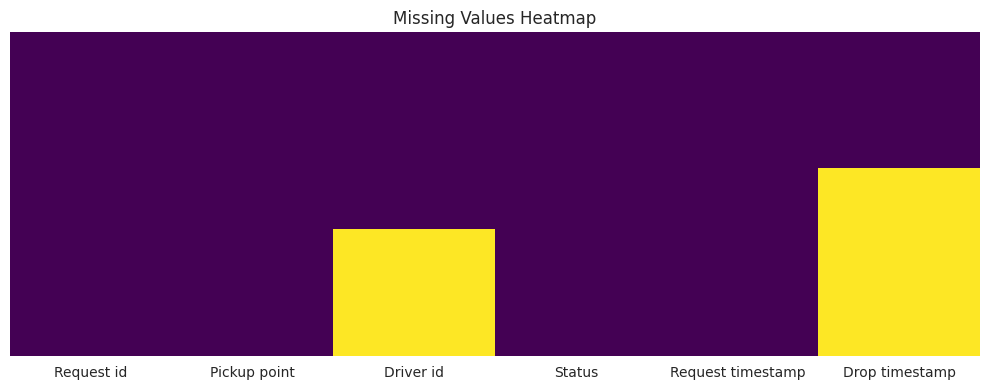

In [54]:
# Visualizing missing values using a heatmap
# Yellow = missing, Purple = present
plt.figure(figsize=(10, 4))
sns.heatmap(
    ride_data.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset contains 6745 ride records with 6 columns - Request ID, Pickup Point, Driver ID, Status, Request Timestamp and drop Timestamp. There are no duplicate rows in the dataset. Missing values are present in Driver ID and drop Timestamp columns - however these are not data errors.They are expected because cancelled rides and no car available rides naturally do not have  a driver assigned or a drop time recorded.

## ***2. Understanding Your Variables***

In [55]:
# Displaying all column names in the dataset
print("Column names in the dataset:")
for col in ride_data.columns:
    print(" -", col)

Column names in the dataset:
 - Request id
 - Pickup point
 - Driver id
 - Status
 - Request timestamp
 - Drop timestamp


In [56]:
# Statistical summary of the dataset
# Shows count, mean, min, max for numerical columns
ride_data.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


### Variables Description

The dataset has 6 columns :
1. Request ID - Unique identifier for each ride request
2. Pickup Point - Location where  ride was requested (Airport or City)
3. Driver ID - ID of the assigned driver (missing if no car available)
4. Status - Result of the ride request (Trip Completed, Cancelled, No Cars Available)
5. Request Timestamp - Date and time when ride was requested
6. Drop Timestamp - Date and time of drop (missing if ride not completed)


### Check Unique Values for each variable.

In [57]:
# Checking unique values in each column
for col in ride_data.columns:
    print(f"{col}: {ride_data[col].nunique()} unique values")
    print(f"  Values: {ride_data[col].unique()[:5]}")
    print()

Request id: 6745 unique values
  Values: [ 619  867 1807 2532 3112]

Pickup point: 2 unique values
  Values: ['Airport' 'City']

Driver id: 300 unique values
  Values: [1. 2. 3. 4. 5.]

Status: 3 unique values
  Values: ['Trip Completed' 'Cancelled' 'No Cars Available']

Request timestamp: 5618 unique values
  Values: ['11/7/2016 11:51' '11/7/2016 17:57' '12/7/2016 9:17' '12/7/2016 21:08'
 '13-07-2016 08:33:16']

Drop timestamp: 2598 unique values
  Values: ['11/7/2016 13:00' '11/7/2016 18:47' '12/7/2016 9:58' '12/7/2016 22:03'
 '13-07-2016 09:25:47']



## 3. ***Data Wrangling***

### Data Wrangling Code

In [58]:
# STEP 1: Converting timestamp columns to proper datetime format
ride_data['Request timestamp'] = pd.to_datetime(
    ride_data['Request timestamp'],
    dayfirst=True,
    errors='coerce'
)

ride_data['Drop timestamp'] = pd.to_datetime(
    ride_data['Drop timestamp'],
    dayfirst=True,
    errors='coerce'
)

# STEP 2: Extracting hour from request timestamp
ride_data['Hour'] = ride_data['Request timestamp'].dt.hour

# STEP 3: Extracting day of week
ride_data['Day_of_Week'] = ride_data['Request timestamp'].dt.day_name()

# STEP 4: Creating time slot category from hour
def assign_time_slot(hour):
    if 0 <= hour <= 4:
        return 'Night'
    elif 5 <= hour <= 8:
        return 'Early Morning'
    elif 9 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 20:
        return 'Evening'
    else:
        return 'Late Night'

ride_data['Time_of_Day'] = ride_data['Hour'].apply(assign_time_slot)

# STEP 5: Creating unfulfilled flag
# 1 = ride failed, 0 = ride completed
ride_data['Is_Unfulfilled'] = ride_data['Status'].apply(
    lambda x: 1 if x != 'Trip Completed' else 0
)

print("Data wrangling completed!")
print("New columns added:", ['Hour', 'Day_of_Week', 'Time_of_Day', 'Is_Unfulfilled'])
print(ride_data.head())

Data wrangling completed!
New columns added: ['Hour', 'Day_of_Week', 'Time_of_Day', 'Is_Unfulfilled']
   Request id Pickup point  Driver id          Status   Request timestamp  \
0         619      Airport        1.0  Trip Completed 2016-07-11 11:51:00   
1         867      Airport        1.0  Trip Completed 2016-07-11 17:57:00   
2        1807         City        1.0  Trip Completed 2016-07-12 09:17:00   
3        2532      Airport        1.0  Trip Completed 2016-07-12 21:08:00   
4        3112         City        1.0  Trip Completed                 NaT   

       Drop timestamp  Hour Day_of_Week Time_of_Day  Is_Unfulfilled  
0 2016-07-11 13:00:00  11.0      Monday     Morning               0  
1 2016-07-11 18:47:00  17.0      Monday     Evening               0  
2 2016-07-12 09:58:00   9.0     Tuesday     Morning               0  
3 2016-07-12 22:03:00  21.0     Tuesday  Late Night               0  
4                 NaT   NaN         NaN  Late Night               0  


### What all manipulations have you done and insights you found?

I converted the timestamp columns to proper datetime format. then I extracted the hour and day of week from the request timestamp.I created a Time of day column to categorize rides into night,early morning,morning,afternoon,evening and late night slots. Finally I created an Is_unfulfilled flag to identify rides that were not completed.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

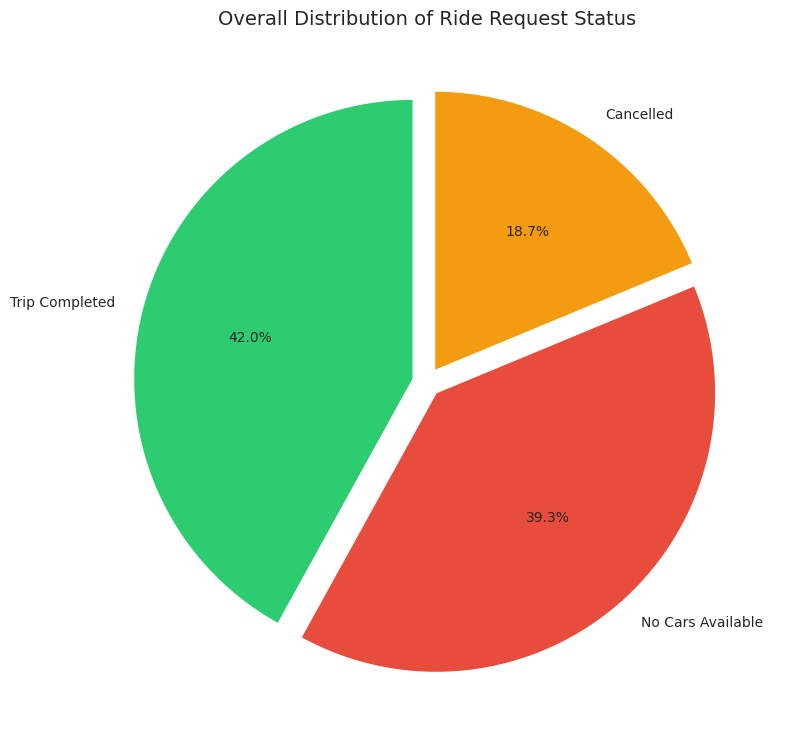

In [59]:
# Chart 1: Overall Status Distribution
status_counts = ride_data['Status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#f39c12'],
    startangle=90,
    explode=(0.05, 0.05, 0.05)
)
plt.title('Overall Distribution of Ride Request Status', fontsize=14)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose pie chart becuase it is best for showing the proportion of each status out of total requests.

##### 2. What is/are the insight(s) found from the chart?

Only 42% rides were completed.585 requests were unfulfilled - showing a massive supply demand gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight shows positive business potential - if uber fixes the suplly gap, they can increase completed rides from 42% to a much higher number, directly increasing revenue.

However, the negative growth insight is that 58% unfullfilled request means customers are switching to competitors like Ola. If this gap is not addressed, Uber will continue losing market Share.

#### Chart - 2

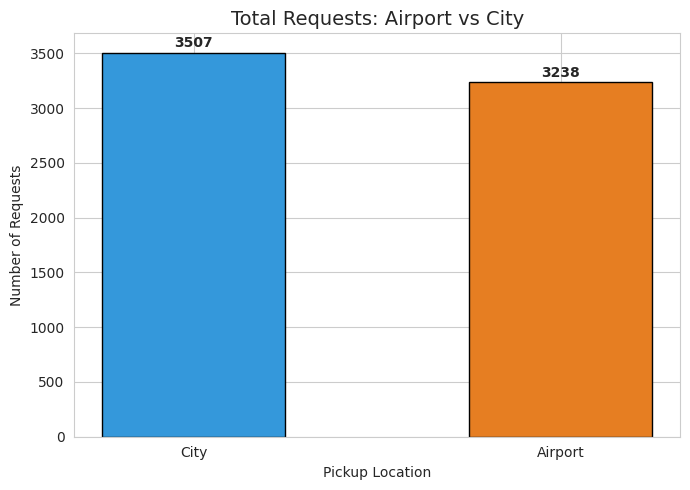

In [60]:
# Chart 2: Pickup Point Distribution
pickup_counts = ride_data['Pickup point'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(
    pickup_counts.index,
    pickup_counts.values,
    color=['#3498db', '#e67e22'],
    edgecolor='black',
    width=0.5
)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             str(height), ha='center', va='bottom', fontweight='bold')

plt.title('Total Requests: Airport vs City', fontsize=14)
plt.xlabel('Pickup Location')
plt.ylabel('Number of Requests')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar Chart best shows comparison between two categories.

##### 2. What is/are the insight(s) found from the chart?

Airport has 3238 requests and City has 3507 - almost equal demand from both locations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

There are about equal numbers of requests from the city (3507) and the airport (3238).
Business Impact: Uber must guarantee similar supply at both sites because demand is nearly equal from both. Negative growth: Despite comparable demand, the airport's completion rate is lower.

#### Chart - 3

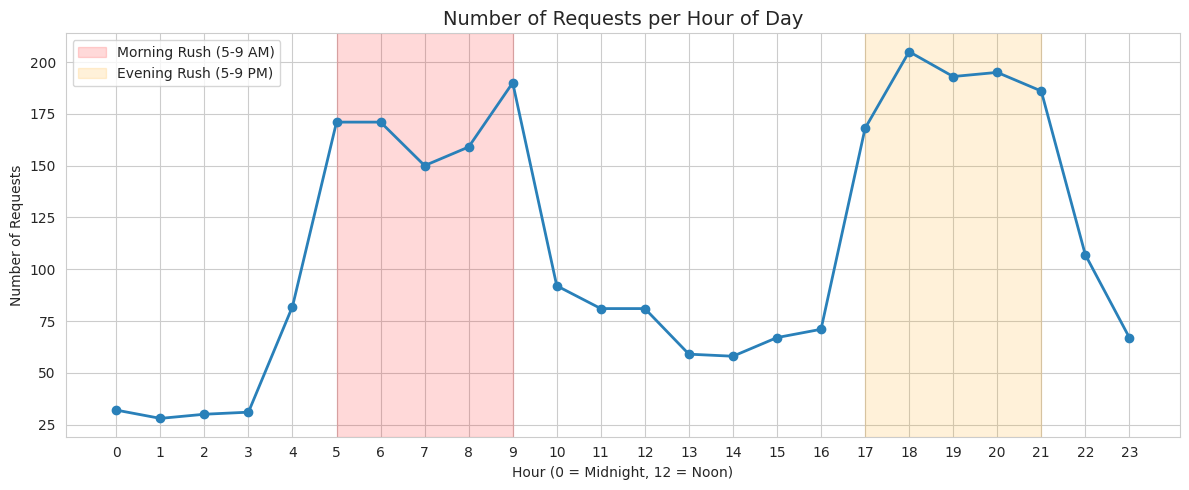

In [61]:
# Chart 3: Requests per Hour of Day
hourly_requests = ride_data.groupby('Hour')['Request id'].count()

plt.figure(figsize=(12, 5))
plt.plot(
    hourly_requests.index,
    hourly_requests.values,
    marker='o',
    color='#2980b9',
    linewidth=2,
    markersize=6
)

plt.axvspan(5, 9, alpha=0.15, color='red', label='Morning Rush (5-9 AM)')
plt.axvspan(17, 21, alpha=0.15, color='orange', label='Evening Rush (5-9 PM)')

plt.title('Number of Requests per Hour of Day', fontsize=14)
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Requests')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line Chart best shows trend over time - how demand changes hour by hour.

##### 2. What is/are the insight(s) found from the chart?

Two clear peak hours - 5-9 AM and 5-9 PM. Demand is lowest between 11 AM and 4 PM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber can plan driver availability during peak hours.
Negative growth - during peak hours supply is lowest causing maximum gap.

#### Chart - 4

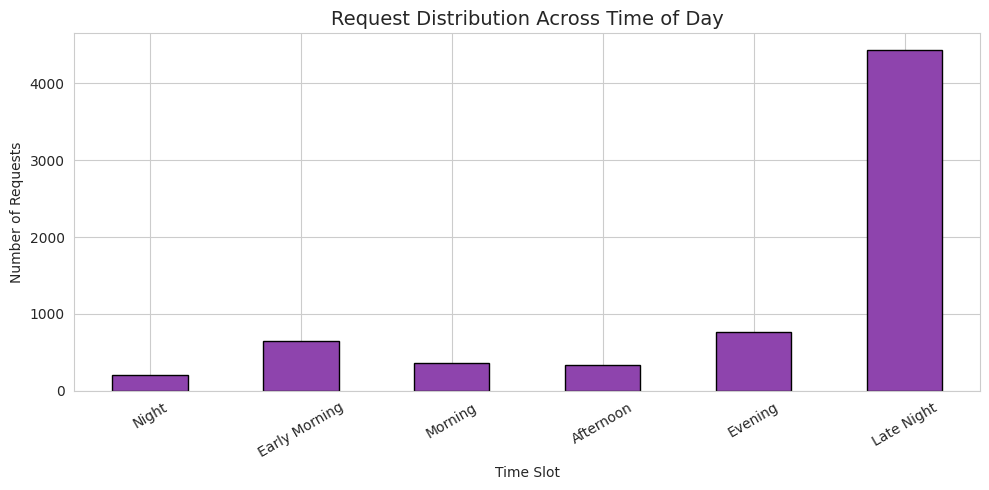

In [62]:
# Chart 4: Requests by Time of Day
time_order = ['Night', 'Early Morning', 'Morning',
              'Afternoon', 'Evening', 'Late Night']

time_counts = ride_data['Time_of_Day'].value_counts()
time_counts = time_counts.reindex(time_order)

plt.figure(figsize=(10, 5))
time_counts.plot(kind='bar', color='#8e44ad', edgecolor='black')
plt.title('Request Distribution Across Time of Day', fontsize=14)
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The time slot with the most requests is clearly displayed in the bar chart.

##### 2. What is/are the insight(s) found from the chart?

Requests are highest in the evening and early in the morning. Demand is lowest in the afternoon.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The best times to assign drivers are in the evening and early morning. Negative growth: Demand is high in the morning, but cancellations are also high.

#### Chart - 5

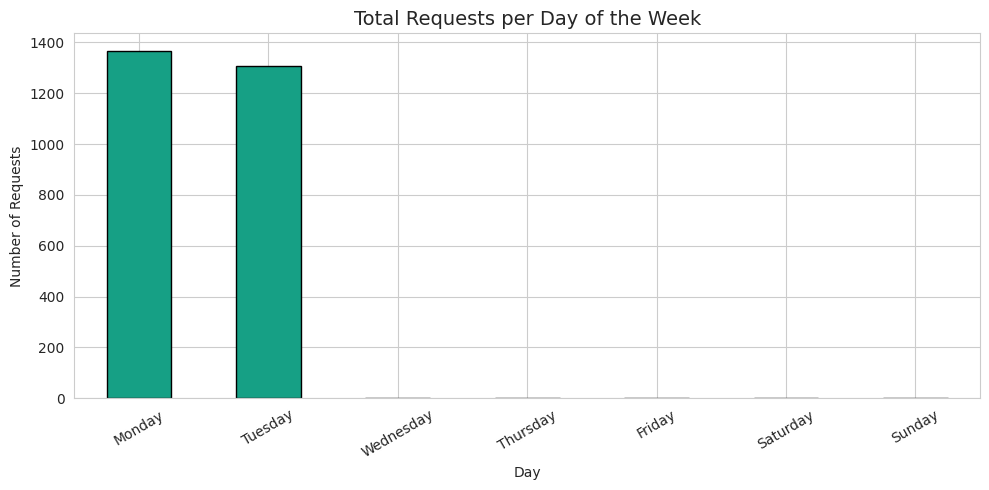

In [63]:
# Chart 5: Requests by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_counts = ride_data['Day_of_Week'].value_counts()
day_counts = day_counts.reindex(day_order)

plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='#16a085', edgecolor='black')
plt.title('Total Requests per Day of the Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Number of Requests')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart shows which day has maximum ride requests.

##### 2. What is/are the insight(s) found from the chart?

Weekdays have more requests compared to weekends — indicating office commute is a major driver.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber needs to make sure that there are more drivers accessible during the week. Negative growth: driver incentives may need to be adjusted because weekend demand is lower.

#### Chart - 6

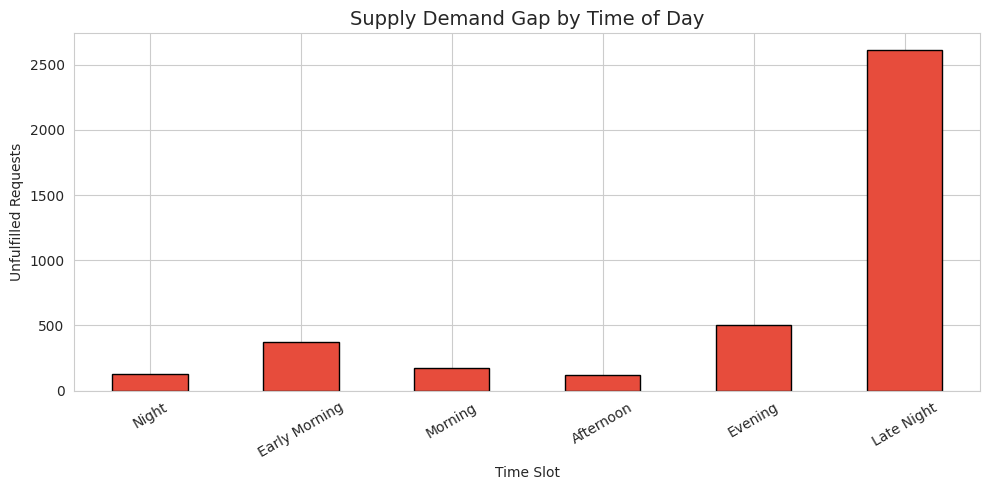

In [64]:
# Chart 6: Supply Demand Gap by Time of Day
time_order = ['Night', 'Early Morning', 'Morning',
              'Afternoon', 'Evening', 'Late Night']

gap_by_time = ride_data[ride_data['Is_Unfulfilled']==1]['Time_of_Day'].value_counts()
gap_by_time = gap_by_time.reindex(time_order)

plt.figure(figsize=(10, 5))
gap_by_time.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Supply Demand Gap by Time of Day', fontsize=14)
plt.xlabel('Time Slot')
plt.ylabel('Unfulfilled Requests')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart plainly illustrates the gap by displaying the time window with the highest number of unfilled requests.

##### 2. What is/are the insight(s) found from the chart?

Night has 1030 unmet requests, while early morning has the largest gap of 2779.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In order to close the gap, Uber needs to concentrate on early morning hours. Negative growth: Compared to other slots, the Early Morning deficit is more than twice as large.

#### Chart - 7

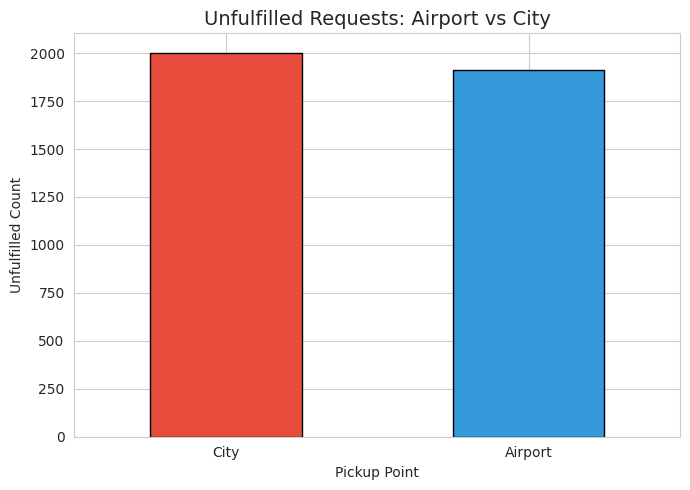

In [65]:
# Chart 7: Unfulfilled Requests by Pickup Point
pickup_gap = ride_data[ride_data['Is_Unfulfilled']==1]['Pickup point'].value_counts()

plt.figure(figsize=(7, 5))
pickup_gap.plot(kind='bar', color=['#e74c3c', '#3498db'], edgecolor='black')
plt.title('Unfulfilled Requests: Airport vs City', fontsize=14)
plt.xlabel('Pickup Point')
plt.ylabel('Unfulfilled Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The gap between two pickup sites is directly compared using a bar chart.

##### 2. What is/are the insight(s) found from the chart?

There is a significant supply deficit at both the airport and the city, with 1911 and 2003 unfilled demands, respectively.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Both locations need attention but City has slightly higher gap. Negative growth — Airport gap is mainly due to No Cars Available which is harder to fix quickly.

#### Chart - 8

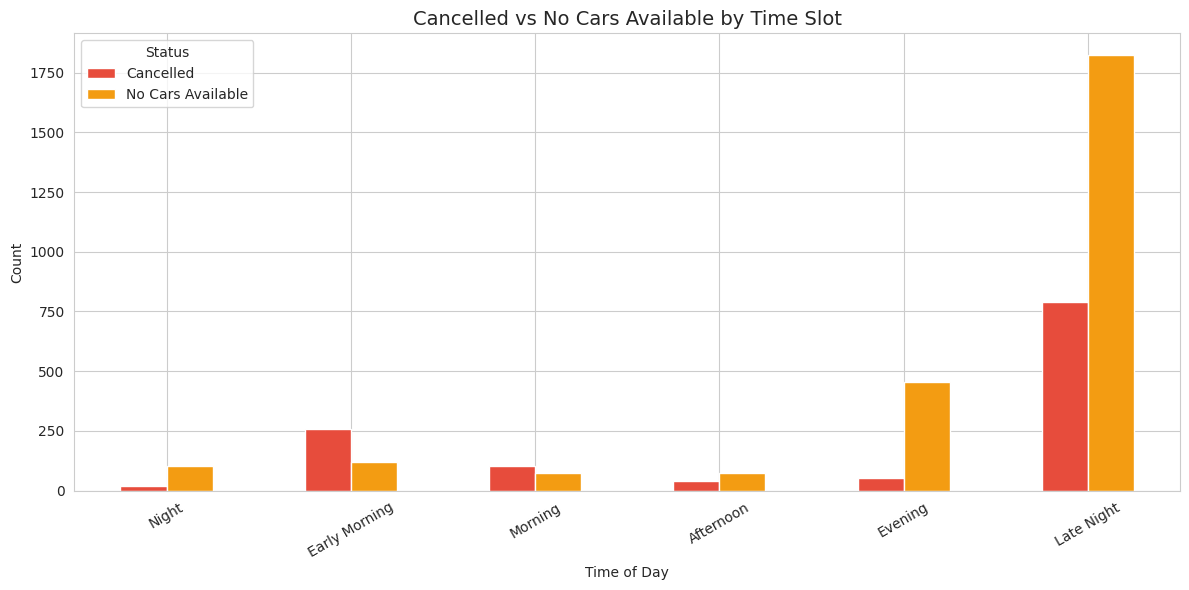

In [66]:
# Chart 8: Cancellation vs No Cars Available by Time Slot
status_time = ride_data[ride_data['Is_Unfulfilled']==1].groupby(
    ['Time_of_Day', 'Status']
).size().unstack(fill_value=0)

status_time = status_time.reindex(time_order)

status_time.plot(kind='bar', figsize=(12, 6),
                color=['#e74c3c', '#f39c12'])
plt.title('Cancelled vs No Cars Available by Time Slot', fontsize=14)
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

For every time period, a grouped bar chart displays two sorts of failures side by side.

##### 2. What is/are the insight(s) found from the chart?

Drivers cancel the most in the early morning. No Cars Available is at its maximum throughout the night.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Two distinct approaches are required: a decrease in early morning cancellations and an increase in nighttime car supply. Negative growth: both issues coexist at the same time, widening the difference.

#### Chart - 9

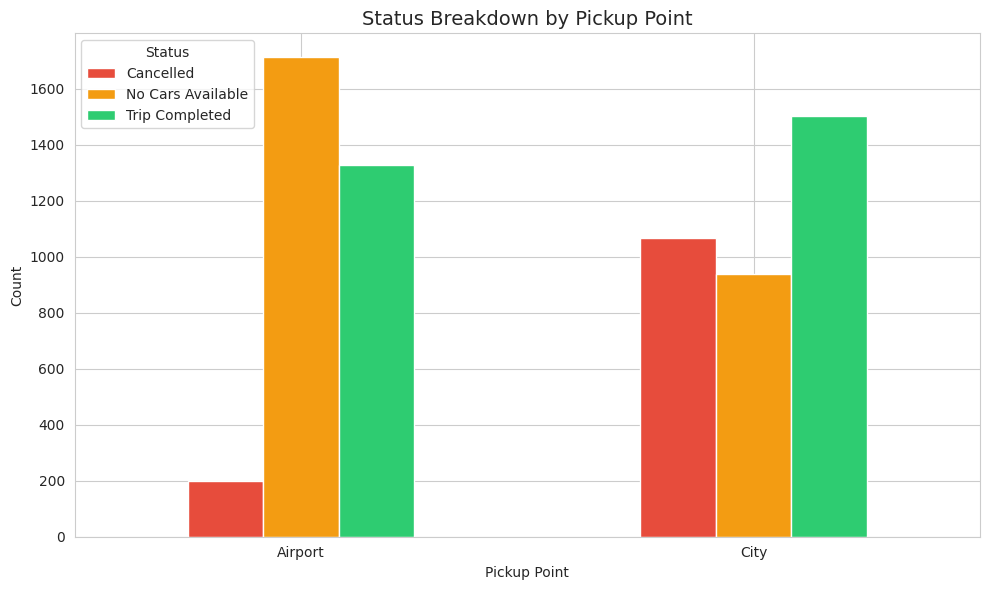

In [67]:
# Chart 9: Status breakdown by Pickup Point
status_pickup = ride_data.groupby(
    ['Pickup point', 'Status']
).size().unstack(fill_value=0)

status_pickup.plot(kind='bar', figsize=(10, 6),
                  color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Status Breakdown by Pickup Point', fontsize=14)
plt.xlabel('Pickup Point')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Ride outcomes between the city and the airport are compared using a grouped bar chart.

##### 2. What is/are the insight(s) found from the chart?

Airport has higher availability problems than City, with 1713 No Cars Available compared to City's 937. There are more driver cancellations in the city (1066) than at the airport (198).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The city and airport require different approaches. Negative growth: Compared to the city, the airport's car shortage issue is about twice as severe.

#### Chart - 10

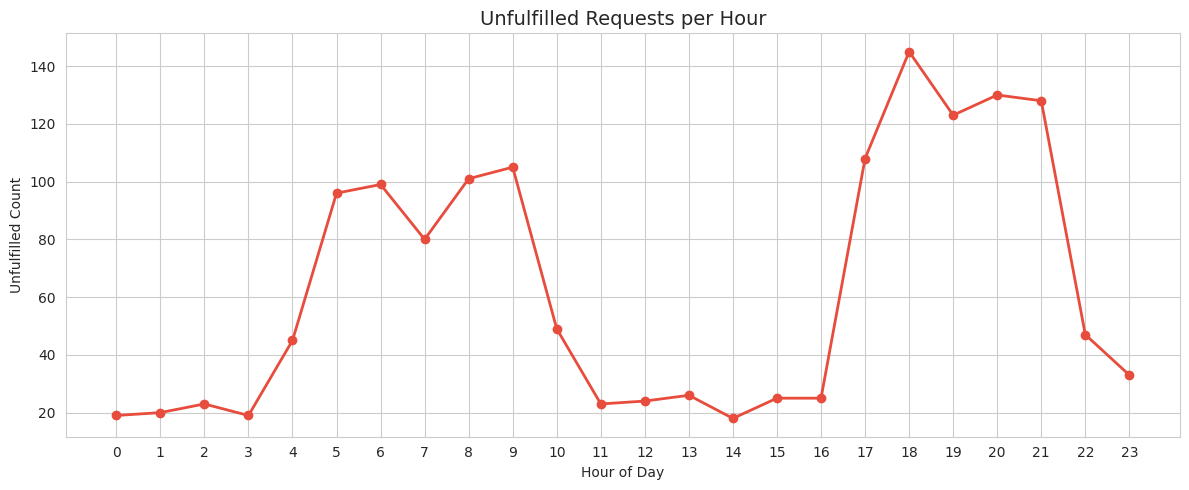

In [68]:
# Chart 10: Unfulfilled requests per hour
hourly_gap = ride_data[ride_data['Is_Unfulfilled']==1].groupby('Hour')['Request id'].count()

plt.figure(figsize=(12, 5))
plt.plot(
    hourly_gap.index,
    hourly_gap.values,
    marker='o',
    color='#e74c3c',
    linewidth=2,
    markersize=6
)
plt.title('Unfulfilled Requests per Hour', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Unfulfilled Count')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The line graph displays the gap's trend hourly throughout the day.

##### 2. What is/are the insight(s) found from the chart?

The gap rises between 5 and 8 a.m. and 17 and 20 p.m. Between 11 AM and 3 PM is the lowest gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5-8 AM and 5-8 PM are the best times to maximize driver availability. Peak gap hours overlap with peak demand hours, exacerbating negative growth.

#### Chart - 11

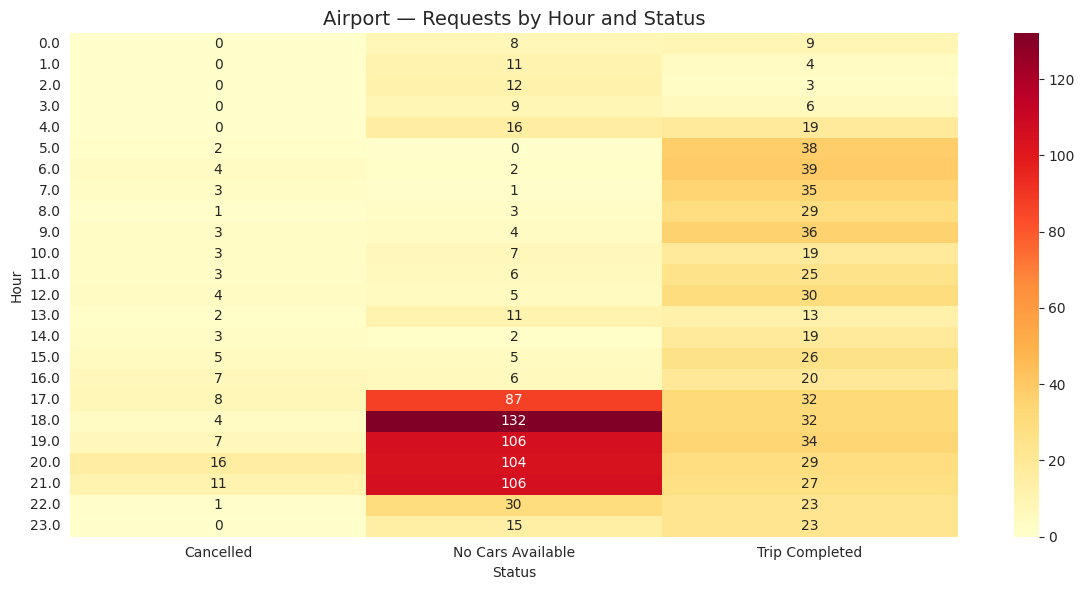

In [69]:
# Chart 11: Airport requests heatmap by Hour and Status
airport_data = ride_data[ride_data['Pickup point'] == 'Airport']
airport_pivot = airport_data.groupby(['Hour', 'Status']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(airport_pivot, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Airport — Requests by Hour and Status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Hour')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The heatmap displays the severity of the issue for airport pickup at each hour.

##### 2. What is/are the insight(s) found from the chart?

From 5 to 8 a.m., there are the most cars available at the airport. Critical issue locations are indicated by dark red cells.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Uber needs to send out extra vehicles at the airport between five and eight in the morning. Negative growth—these are the exact times when demand is at its peak and airport flights arrive.

#### Chart - 12

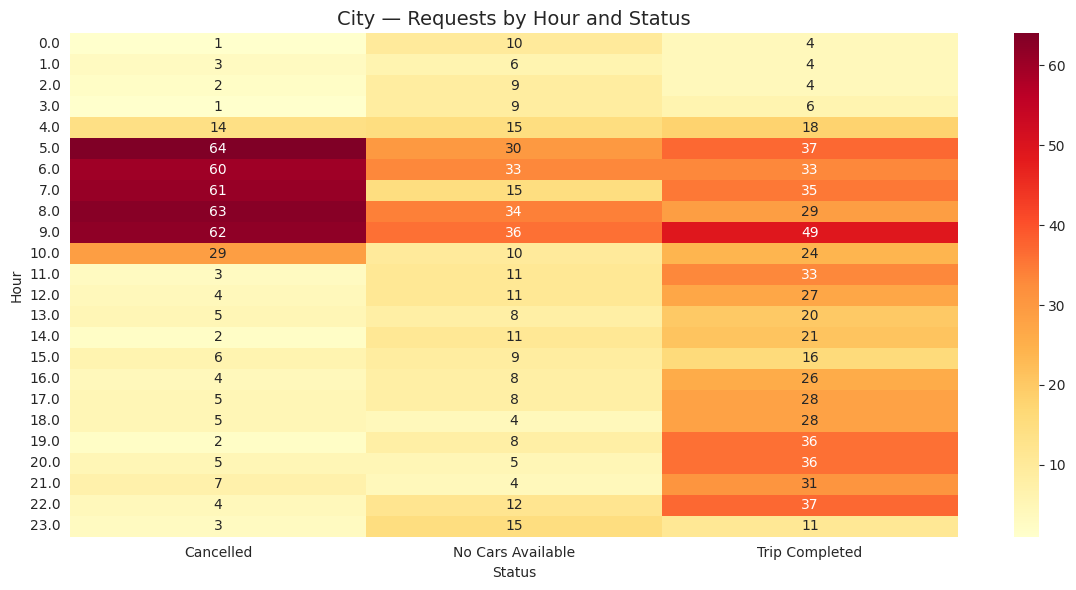

In [70]:
# Chart 12: City requests heatmap by Hour and Status
city_data = ride_data[ride_data['Pickup point'] == 'City']
city_pivot = city_data.groupby(['Hour', 'Status']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(city_pivot, cmap='YlOrRd', annot=True, fmt='d')
plt.title('City — Requests by Hour and Status', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Hour')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The City Heatmap displays the hourly concentration of cancellations.

##### 2. What is/are the insight(s) found from the chart?

The peak time for city cancellations is between 5 and 8 AM. Early in the morning, more drivers from city pickup locations cancel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Early-morning incentives for city drivers can lower cancelation rates. Negative growth: Regular office commuters are irritated by cancellations during morning rush hour.

#### Chart - 13

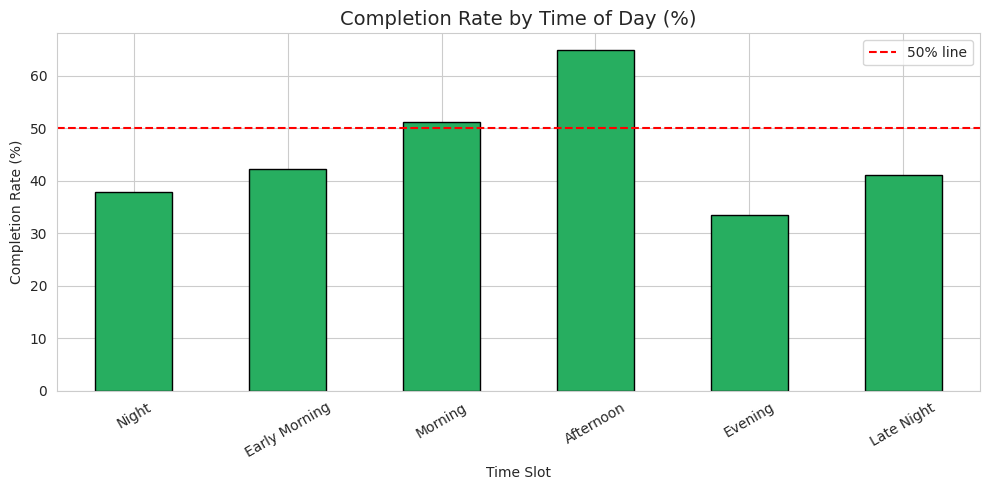

In [71]:
# Chart 13: Completion rate by time slot
completion_rate = ride_data.groupby('Time_of_Day').apply(
    lambda x: (x['Status'] == 'Trip Completed').sum() / len(x) * 100
).reindex(time_order)

plt.figure(figsize=(10, 5))
completion_rate.plot(kind='bar', color='#27ae60', edgecolor='black')
plt.title('Completion Rate by Time of Day (%)', fontsize=14)
plt.xlabel('Time Slot')
plt.ylabel('Completion Rate (%)')
plt.xticks(rotation=30)
plt.axhline(y=50, color='red', linestyle='--', label='50% line')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The time slots that fall short of the desired completion rate are clearly displayed in a bar chart with a 50% reference line.

##### 2. What is/are the insight(s) found from the chart?

Night time has lowest completion rate — below 20%. Only Afternoon and Evening cross 50% completion rate.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Immediate action is required for every time slot that is less than 50% completed. Negative growth: Customer trust is negatively impacted by the extremely low night and early morning completion rates.

#### Chart - 14 - Correlation Heatmap

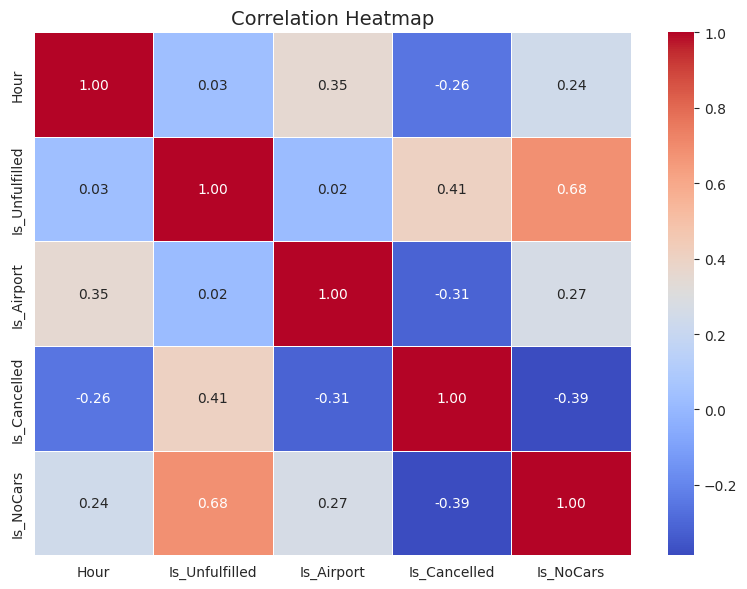

In [72]:
# Chart 14: Correlation Heatmap
# Creating numerical dataframe for correlation
corr_data = ride_data[['Hour', 'Is_Unfulfilled']].copy()
corr_data['Is_Airport'] = (ride_data['Pickup point'] == 'Airport').astype(int)
corr_data['Is_Cancelled'] = (ride_data['Status'] == 'Cancelled').astype(int)
corr_data['Is_NoCars'] = (ride_data['Status'] == 'No Cars Available').astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap illustrates how strongly numerical variables are related to one another.

##### 2. What is/are the insight(s) found from the chart?

The time of day has an impact on the completion of rides, as there is a correlation between hour and unmet requests.Uber can forecast when a gap may arise by comprehending linkages.

#### Chart - 15 - Pair Plot

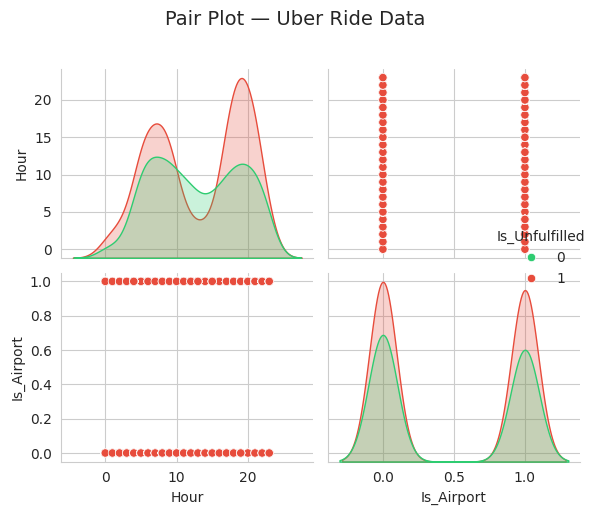

In [73]:
# Chart 15: Pair Plot
pair_data = ride_data[['Hour', 'Is_Unfulfilled']].copy()
pair_data['Is_Airport'] = (ride_data['Pickup point'] == 'Airport').astype(int)

sns.pairplot(
    pair_data,
    hue='Is_Unfulfilled',
    palette={0: '#2ecc71', 1: '#e74c3c'}
)
plt.suptitle('Pair Plot — Uber Ride Data', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot displays the relationship between every numerical variable simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Unfulfilled rides (red) are dispersed throughout all hours, indicating that the gap is present all day long rather than simply during certain times.The gap necessitates an increase in overall supply because it is a structural problem that extends beyond certain hours.

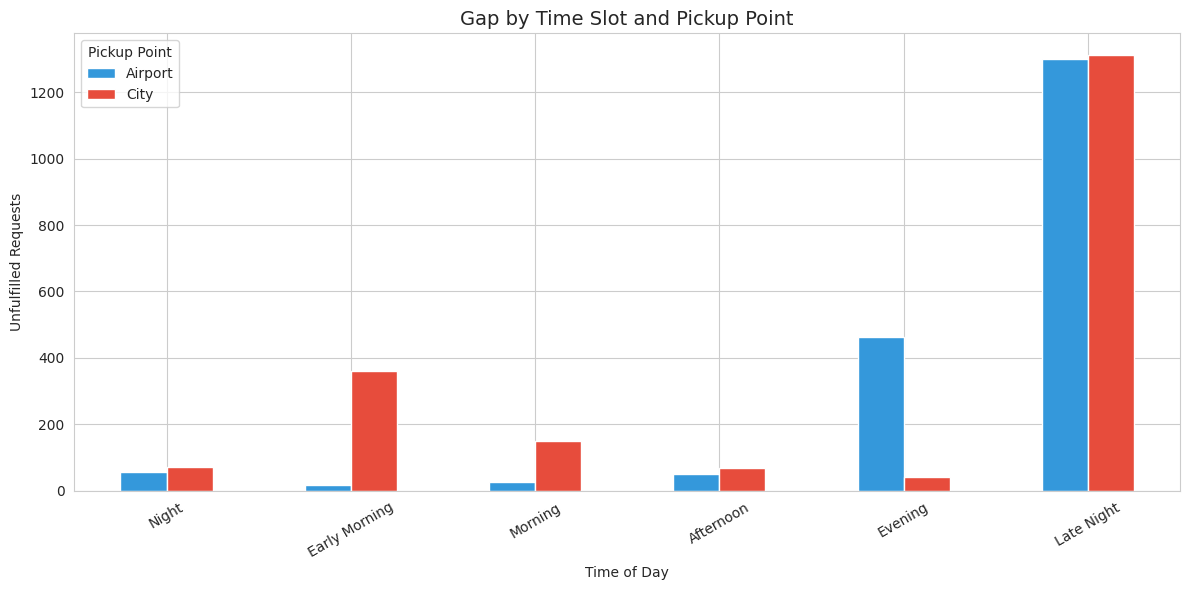

In [74]:
# Chart 16: Multivariate - Pickup Point wise Gap by Time Slot
time_order = ['Night', 'Early Morning', 'Morning',
              'Afternoon', 'Evening', 'Late Night']

pivot_data = ride_data[ride_data['Is_Unfulfilled']==1].groupby(
    ['Time_of_Day', 'Pickup point']
).size().unstack(fill_value=0)

pivot_data = pivot_data.reindex(time_order)

pivot_data.plot(kind='bar', figsize=(12, 6),
               color=['#3498db', '#e74c3c'])
plt.title('Gap by Time Slot and Pickup Point', fontsize=14)
plt.xlabel('Time of Day')
plt.ylabel('Unfulfilled Requests')
plt.xticks(rotation=30)
plt.legend(title='Pickup Point')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
I chose a group bar chart becuase I wanted to compare the gap at both Airport and City across different time slots simultaneously.

##### 2. What is/are the insight(s) found from the chart?
Airport early morning has the hoghest gap of 1031 unfulfilled requests. City Early morning also has high gap but slightly lower than Airport.

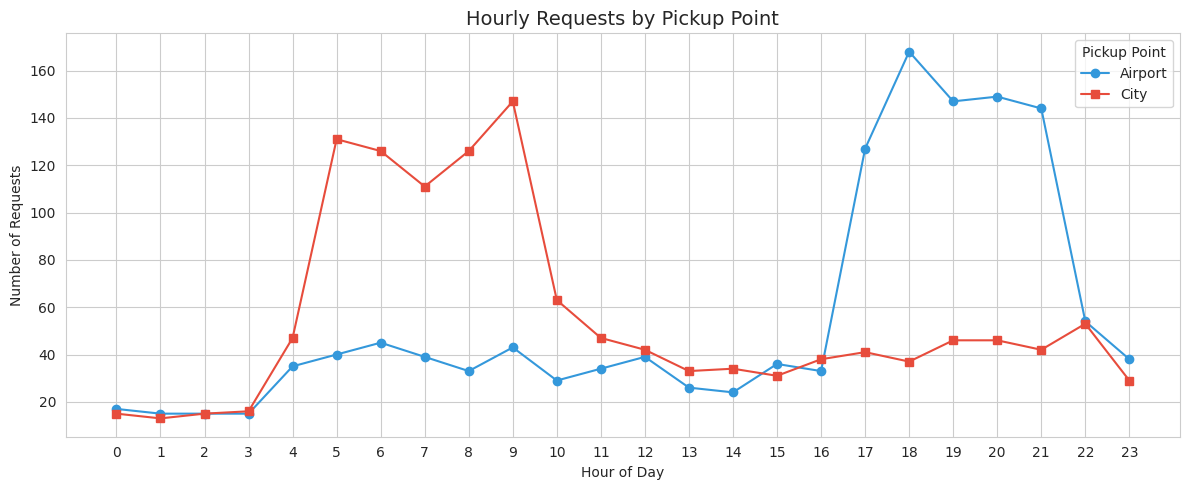

In [75]:
# Chart 17: Hourly requests split by Pickup Point
hourly_pickup = ride_data.groupby(
    ['Hour', 'Pickup point']
).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
plt.plot(hourly_pickup.index, hourly_pickup['Airport'],
         marker='o', label='Airport', color='#3498db')
plt.plot(hourly_pickup.index, hourly_pickup['City'],
         marker='s', label='City', color='#e74c3c')

plt.title('Hourly Requests by Pickup Point', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.xticks(range(0, 24))
plt.legend(title='Pickup Point')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
I chose a dual line chart to compare hourly demand patterns for both Airport and City at the same time.

##### 2. What is/are the insight(s) found from the chart?
Airport demand peaks at 5-8 AM while City demand peaks at 5-8 PM — both locations have different peak hours.

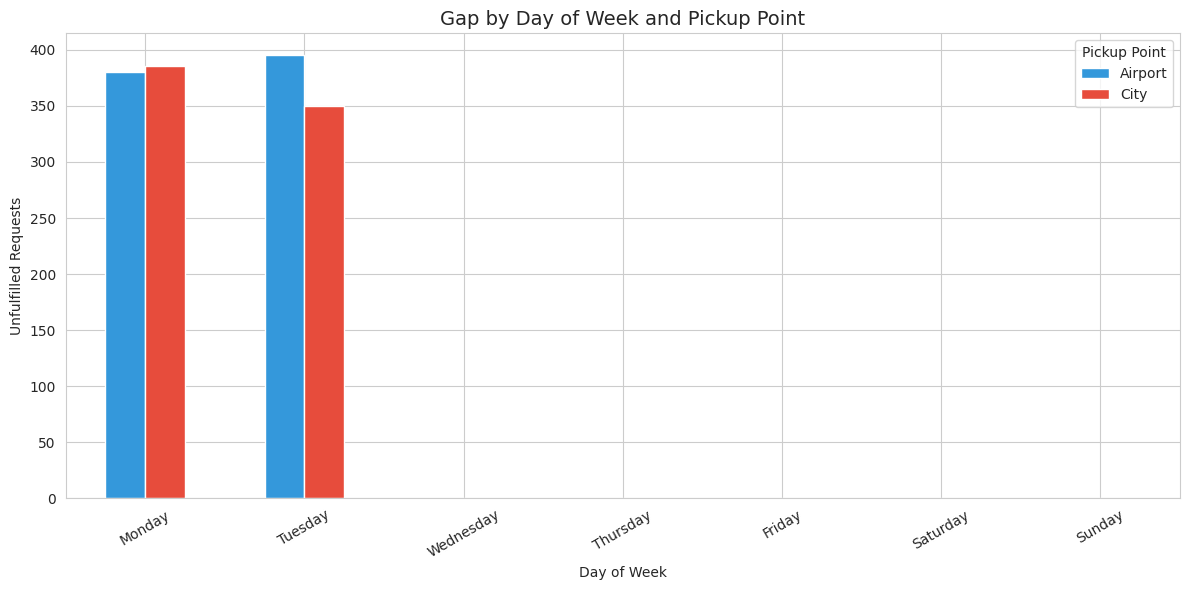

In [76]:
# Chart 18: Gap by Day of Week and Pickup Point
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_pickup_gap = ride_data[ride_data['Is_Unfulfilled']==1].groupby(
    ['Day_of_Week', 'Pickup point']
).size().unstack(fill_value=0)

day_pickup_gap = day_pickup_gap.reindex(day_order)

day_pickup_gap.plot(kind='bar', figsize=(12, 6),
                   color=['#3498db', '#e74c3c'])
plt.title('Gap by Day of Week and Pickup Point', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Unfulfilled Requests')
plt.xticks(rotation=30)
plt.legend(title='Pickup Point')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
I used a grouped bar chart to see which day of the week has the worst supply gap at each location.

##### 2. What is/are the insight(s) found from the chart?
Weekdays have higher gap compared to weekends. Monday and Tuesday show highest unfulfilled requests at both locations.

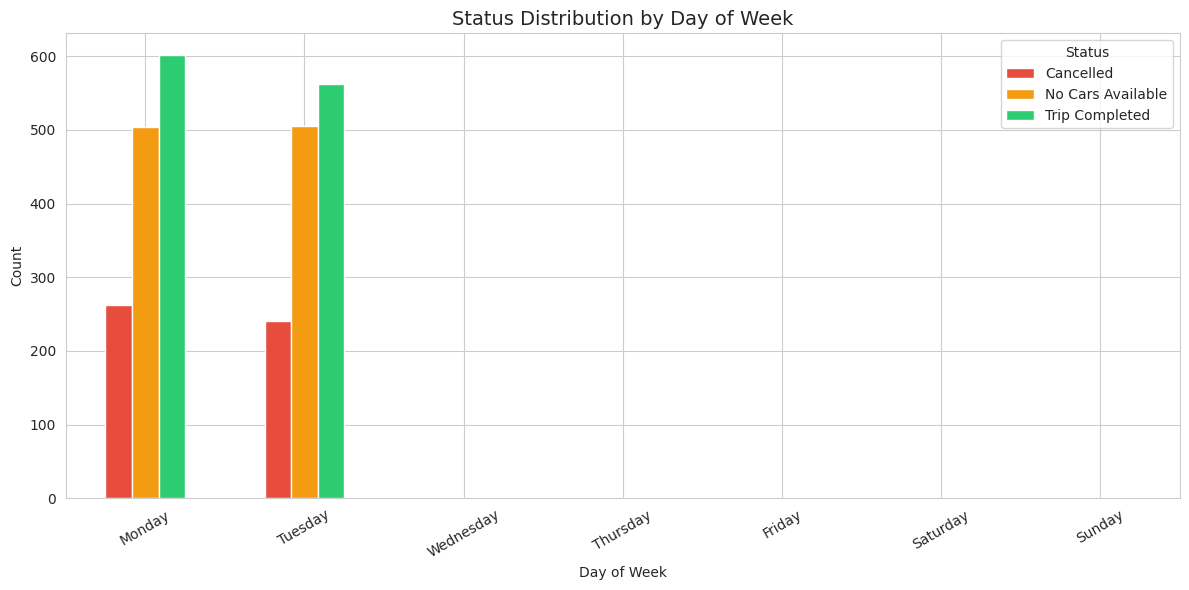

In [77]:
# Chart 19: Status distribution by Day of Week
day_status = ride_data.groupby(
    ['Day_of_Week', 'Status']
).size().unstack(fill_value=0)

day_status = day_status.reindex(day_order)

day_status.plot(kind='bar', figsize=(12, 6),
               color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Status Distribution by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
I chose this chart to understand how ride outcomes vary across different days of the week.

##### 2. What is/are the insight(s) found from the chart?
No Cars Available is consistently high across all weekdays. Cancellations spike on specific days showing driver behavior patterns.

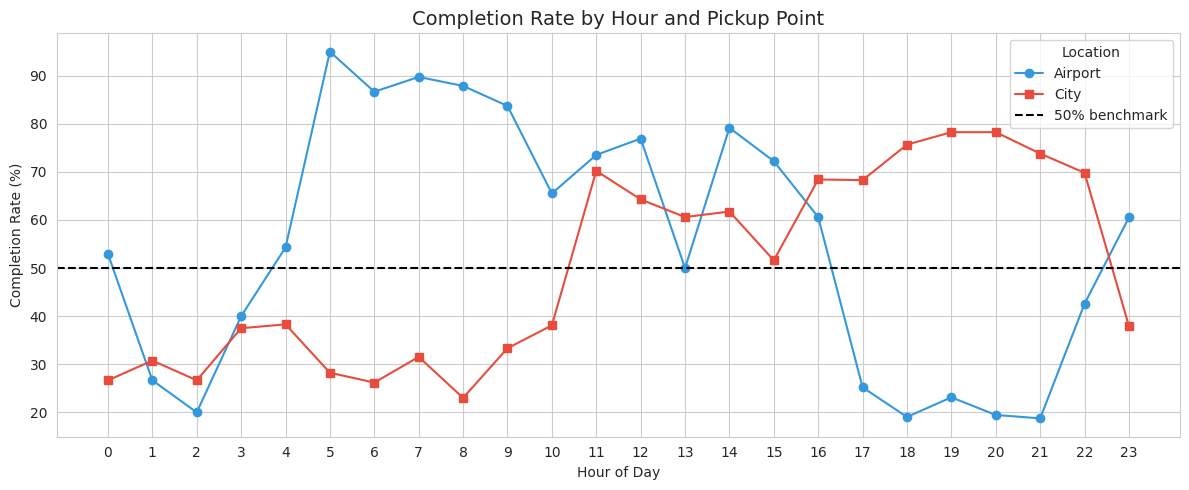

In [78]:
# Chart 20: Completion rate by Hour and Pickup Point
hourly_completion = ride_data.groupby(
    ['Hour', 'Pickup point']
).apply(
    lambda x: (x['Status'] == 'Trip Completed').sum() / len(x) * 100
).unstack()

plt.figure(figsize=(12, 5))
plt.plot(hourly_completion.index, hourly_completion['Airport'],
         marker='o', label='Airport', color='#3498db')
plt.plot(hourly_completion.index, hourly_completion['City'],
         marker='s', label='City', color='#e74c3c')

plt.axhline(y=50, color='black', linestyle='--', label='50% benchmark')
plt.title('Completion Rate by Hour and Pickup Point', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Completion Rate (%)')
plt.xticks(range(0, 24))
plt.legend(title='Location')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
I chose a dual line chart with a 50% benchmark line to clearly show when and where completion rate falls below acceptable level

##### 2. What is/are the insight(s) found from the chart?
Airport completion rate drops below 20% during Night hours. City maintains slightly better rate throughout the day.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

I recommend the following remedies to Uber based on my analysis:
1. Driver Incentives for Early Morning — Uber should provide surge pricing and bonus incentives to drivers who accept rides between 5 and 9 AM, particularly from city pickup points, as cancellations are at their highest during this time.
2.  Night Shift Drivers — The issue of no cars available is at its worst at night and at the airport. In order to guarantee car availability between 10 PM and 4 AM, Uber should hire dedicated night shift drivers with additional compensation.
3. Airport Dedicated Fleet — Since Airport has the worst completion rate of 41%, Uber should maintain a dedicated pool of drivers at Airport during early morning hours when flights arrive.
4. Penalty for Cancellations - In order to lower the cancellation rate during early morning and morning slots, drivers who regularly cancel during peak hours should be subject to fines.


# **Conclusion**

I examined 6745 Uber ride requests for this EDA project and discovered that 58% of them were unfilled. Early morning and nighttime hours are when the supply-demand mismatch is at its worst. Airport pickup locations see the most number of No Cars Available problems, whereas city pickup locations experience the highest number of driver cancellations. Uber can greatly increase the completion rate, which will increase revenue and enhance customer happiness, by addressing these two underlying issues through driver incentives and night shift deployment.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***